# Defensive AI — Binary Attack Classification (XGBoost)
## PFE 2025 — Mohamed Bouzira & Bakhti Rayane Abderaouef

**Objective:** Build a binary classifier to detect whether network traffic is **benign** or **attack** using XGBoost on real honeypot data (2.6M logs collected from a cloud-deployed IoT smart-home honeypot).

**Pipeline:**
1. Load & Explore Data (EDA)
2. Data Cleaning & Preprocessing
3. Feature Engineering
4. Feature Selection
5. Train/Test Split
6. Model Training (XGBoost)
7. Hyperparameter Tuning (RandomizedSearchCV)
8. Evaluation & Cross-Validation
9. Save Model

In [3]:
# ================================================================
# Cell 1: Install Dependencies & Imports
# ================================================================
!pip install pandas numpy matplotlib seaborn scikit-learn xgboost imbalanced-learn -q

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

pd.set_option('display.max_columns', 60)
pd.set_option('display.width', 200)
sns.set_style('whitegrid')
plt.rcParams['figure.dpi'] = 100

In [4]:
# ================================================================
# Cell 2: Load Dataset
# ================================================================
df = pd.read_csv('honeypot_dataset.csv')

print(f"Dataset shape: {df.shape}")
print(f"Memory usage: {df.memory_usage(deep=True).sum() / 1024**2:.1f} MB")
print(f"\nColumn types:\n{df.dtypes.value_counts()}")
print(f"\nFirst 5 rows:")
df.head()

Dataset shape: (33311, 46)
Memory usage: 52.8 MB

Column types:
object     26
float64    19
bool        1
Name: count, dtype: int64

First 5 rows:


,bytes_sent,bytes_received,src_port,dst_port,payload_size,body_size,qos,msg_rate_per_min,req_rate_per_min,session_msg_count,session_topic_count,session_req_count,session_endpoint_count,session_path_count,session_duration_s,http_status_code,packet_count,pps,window_seconds,attack_type,is_attack,log_type,protocol,@timestamp,src_ip,dst_ip,is_internal,is_known_device,mqtt_action,client_id,topic,retain,is_known_topic,http_method,http_endpoint,user_agent,coap_method,coap_path,coap_response_code,is_known_path,eventid,username,login_success,attack_name,login_attempt,username_tried
0,96.707507,0.0,0.000000,1883.0,96.707507,0.0,0.0,15.471671,0.000000,2.17611,4.588055,0.000000,0.000000,0.000000,346.590519,0.0,0.0,0.0,0.0,topic_anomaly,True,mqtt,MQTT,synthetic,synthetic,synthetic,synthetic,synthetic,synthetic,synthetic,synthetic,synthetic,synthetic,synthetic,synthetic,synthetic,synthetic,synthetic,synthetic,synthetic,synthetic,synthetic,synthetic,synthetic,synthetic,synthetic
1,0.000000,0.0,52243.150625,5683.0,0.000000,0.0,0.0,0.000000,20.657833,0.00000,0.000000,6.625292,0.000000,7.171083,43.636853,0.0,0.0,0.0,0.0,path_scan,True,coap,CoAP,synthetic,synthetic,synthetic,synthetic,synthetic,synthetic,synthetic,synthetic,synthetic,synthetic,synthetic,synthetic,synthetic,synthetic,synthetic,synthetic,synthetic,synthetic,synthetic,synthetic,synthetic,synthetic,synthetic
2,0.000000,0.0,0.000000,1883.0,0.000000,0.0,0.0,6.632874,0.000000,1.55069,2.000000,0.000000,0.000000,0.000000,27.121866,0.0,0.0,0.0,0.0,wildcard_scan,True,mqtt,MQTT,synthetic,synthetic,synthetic,synthetic,synthetic,synthetic,synthetic,synthetic,synthetic,synthetic,synthetic,synthetic,synthetic,synthetic,synthetic,synthetic,synthetic,synthetic,synthetic,synthetic,synthetic,synthetic,synthetic
3,0.000000,0.0,58798.000000,5683.0,0.000000,0.0,0.0,0.000000,9.000000,0.00000,0.000000,3128.000000,0.000000,2.000000,20859.190000,0.0,0.0,0.0,0.0,benign,False,coap,CoAP,2026-04-22T06:27:39.600Z,172.20.0.15,172.20.0.2,True,True,synthetic,synthetic,synthetic,synthetic,synthetic,synthetic,synthetic,synthetic,GET,home/motion/command,2.05 Content,True,synthetic,synthetic,synthetic,synthetic,synthetic,synthetic
4,33.000000,0.0,38778.000000,80.0,0.000000,33.0,0.0,0.000000,19.000000,0.00000,0.000000,34.769437,34.769437,0.000000,111.122224,404.0,0.0,0.0,0.0,unknown_external,True,platform,HTTP,synthetic,synthetic,synthetic,synthetic,synthetic,synthetic,synthetic,synthetic,synthetic,synthetic,synthetic,synthetic,synthetic,synthetic,synthetic,synthetic,synthetic,synthetic,synthetic,synthetic,synthetic,synthetic,synthetic


# Cell 3: Dataset Overview & Class Distribution

In [5]:
# ================================================================
# Cell 3: Dataset Overview & Class Distribution
# ================================================================
print("=" * 60)
print("DATASET OVERVIEW")
print("=" * 60)

print(f"\nTotal samples: {len(df):,}")
print(f"Features: {df.shape[1]}")
print(f"\nMissing values (top 15):")
missing = df.isnull().sum()
print(missing[missing > 0].sort_values(ascending=False).head(15))

print(f"\n{'=' * 60}")
print("BINARY CLASS DISTRIBUTION")
print("=" * 60)

print(f"\nis_attack value counts:")
print(df["is_attack"].value_counts())
print(f"\nAttack ratio: {df['is_attack'].mean():.2%}")

print(f"\n--- Per Protocol ---")
print(df.groupby(["log_type", "is_attack"]).size().unstack(fill_value=0))

print(f"\n--- Attack types (multiclass breakdown) ---")
if "attack_type" in df.columns:
    print(df["attack_type"].value_counts())

DATASET OVERVIEW

Total samples: 33,311
Features: 46

Missing values (top 15):
src_ip                1
dst_ip                1
is_internal           1
is_known_device       1
mqtt_action           1
client_id             1
topic                 1
retain                1
is_known_topic        1
http_method           1
http_endpoint         1
user_agent            1
coap_method           1
coap_path             1
coap_response_code    1
dtype: int64

BINARY CLASS DISTRIBUTION

is_attack value counts:
is_attack
True     22995
False    10316
Name: count, dtype: int64

Attack ratio: 69.03%

--- Per Protocol ---
is_attack  False  True 
log_type               
coap        3432   2533
cowrie        23   4753
http        3433   4200
mqtt        3372   5036
network       25   1629
platform      31   4844

--- Attack types (multiclass breakdown) ---
attack_type
benign              10316
topic_anomaly        1698
path_scan            1685
endpoint_scan        1668
wildcard_scan        1664
unknown

# Cell 4: Exploratory Data Analysis (EDA) — Visualizations

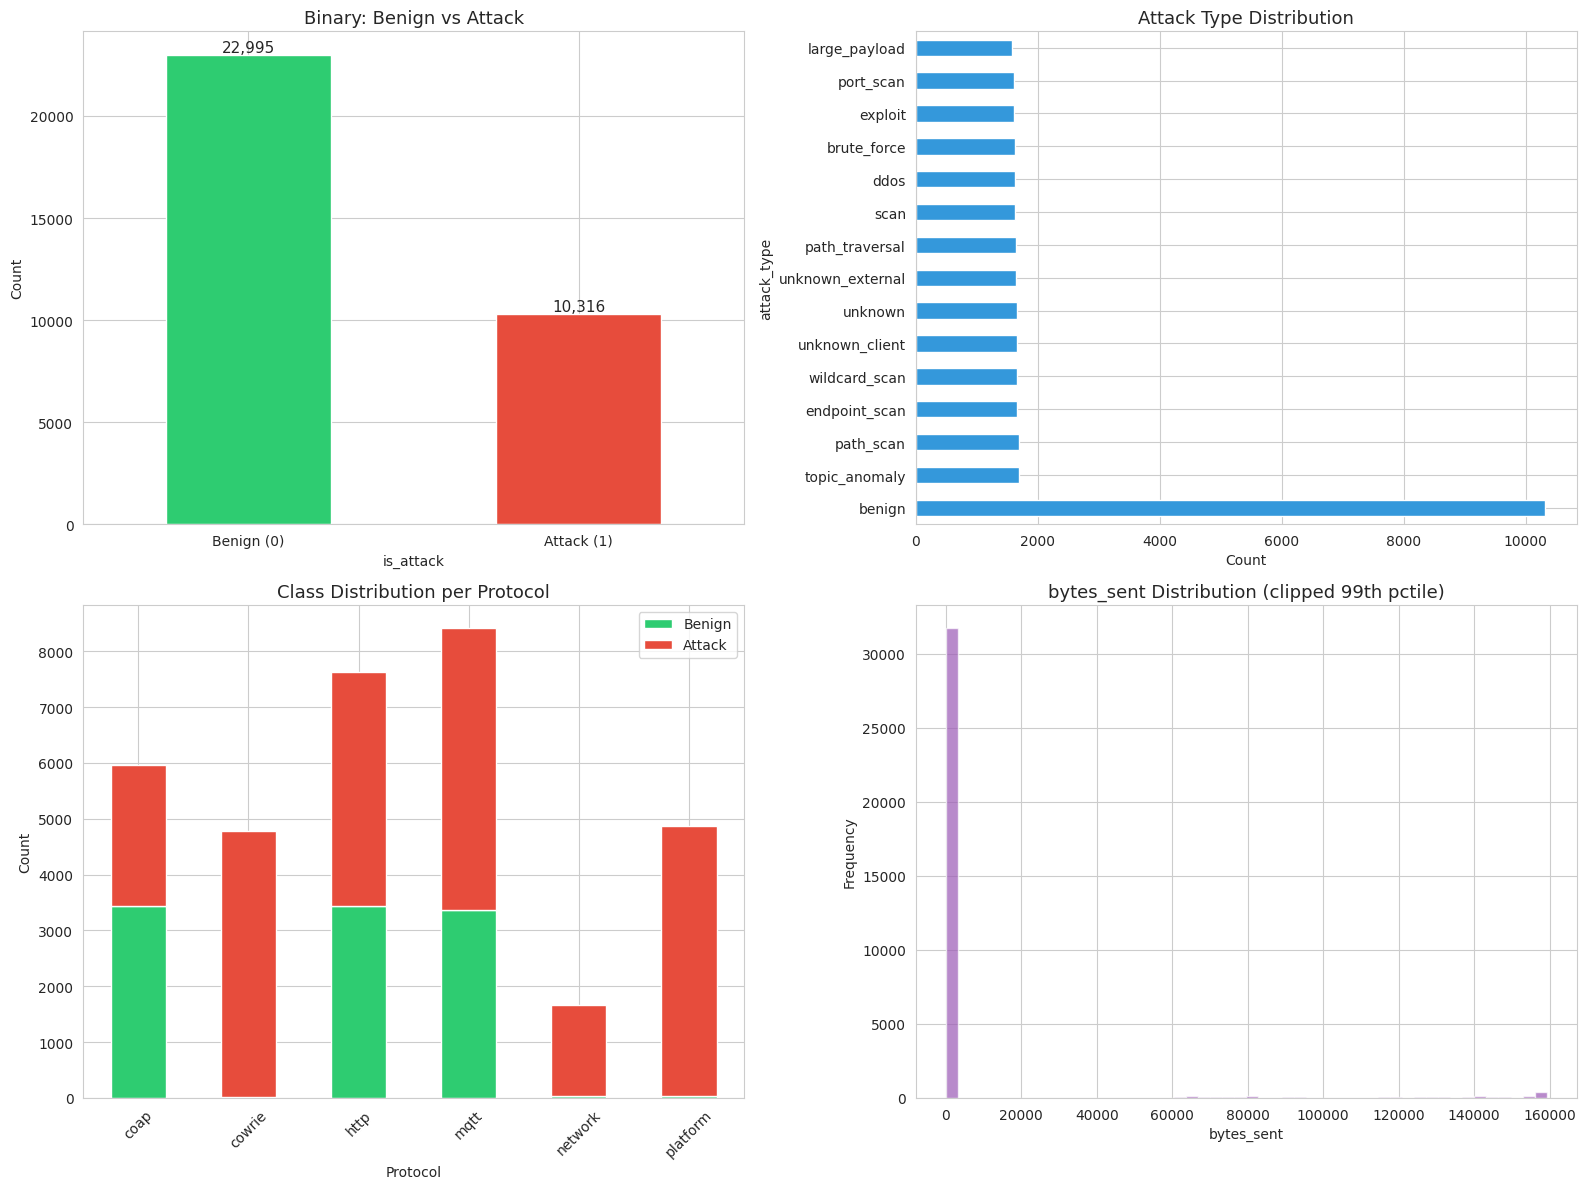

In [6]:
# ================================================================
# Cell 4: EDA Visualizations
# ================================================================
fig, axes = plt.subplots(2, 2, figsize=(16, 12))

# 1. Binary class balance
df["is_attack"].value_counts().plot.bar(ax=axes[0, 0], color=["#2ecc71", "#e74c3c"])
axes[0, 0].set_title("Binary: Benign vs Attack", fontsize=13)
axes[0, 0].set_xticklabels(["Benign (0)", "Attack (1)"], rotation=0)
axes[0, 0].set_ylabel("Count")
for p in axes[0, 0].patches:
    axes[0, 0].annotate(f'{int(p.get_height()):,}', (p.get_x() + p.get_width()/2., p.get_height()),
                        ha='center', va='bottom', fontsize=11)

# 2. Attack type distribution
if "attack_type" in df.columns:
    attack_counts = df["attack_type"].value_counts()
    attack_counts.plot.barh(ax=axes[0, 1], color="#3498db")
    axes[0, 1].set_title("Attack Type Distribution", fontsize=13)
    axes[0, 1].set_xlabel("Count")

# 3. Protocol distribution by class
ct = pd.crosstab(df["log_type"], df["is_attack"])
ct.plot.bar(ax=axes[1, 0], color=["#2ecc71", "#e74c3c"], stacked=True)
axes[1, 0].set_title("Class Distribution per Protocol", fontsize=13)
axes[1, 0].set_xlabel("Protocol")
axes[1, 0].set_ylabel("Count")
axes[1, 0].legend(["Benign", "Attack"])
axes[1, 0].tick_params(axis='x', rotation=45)

# 4. Numerical feature distributions (bytes_sent)
df["bytes_sent"].clip(upper=df["bytes_sent"].quantile(0.99)).hist(
    ax=axes[1, 1], bins=50, color="#9b59b6", alpha=0.7)
axes[1, 1].set_title("bytes_sent Distribution (clipped 99th pctile)", fontsize=13)
axes[1, 1].set_xlabel("bytes_sent")
axes[1, 1].set_ylabel("Frequency")

plt.tight_layout()
plt.show()

# Cell 5: Correlation Heatmap & Numerical Statistics

Numerical features (19):
                          count      mean       std  min    25%       50%       75%        max
bytes_sent              33311.0   6038.02  28292.57  0.0   0.00      0.00    109.00  199681.63
bytes_received          33311.0      0.36     15.04  0.0   0.00      0.00      0.00     996.00
src_port                33311.0  26068.42  24134.17  0.0   0.00  33684.00  48192.93   65522.00
dst_port                33311.0   3413.33   3182.06  0.0  80.00   1883.00   5683.00    8080.00
payload_size            33311.0     31.74     87.99  0.0   0.00      0.00      0.00    4738.00
body_size               33311.0   5996.62  28293.79  0.0   0.00      0.00      0.00  199681.63
qos                     33311.0      0.00      0.01  0.0   0.00      0.00      0.00       1.00
msg_rate_per_min        33311.0      2.09      6.33  0.0   0.00      0.00      1.17     477.00
req_rate_per_min        33311.0     78.14    329.18  0.0   0.00      3.00      9.00    3000.00
session_msg_count       3

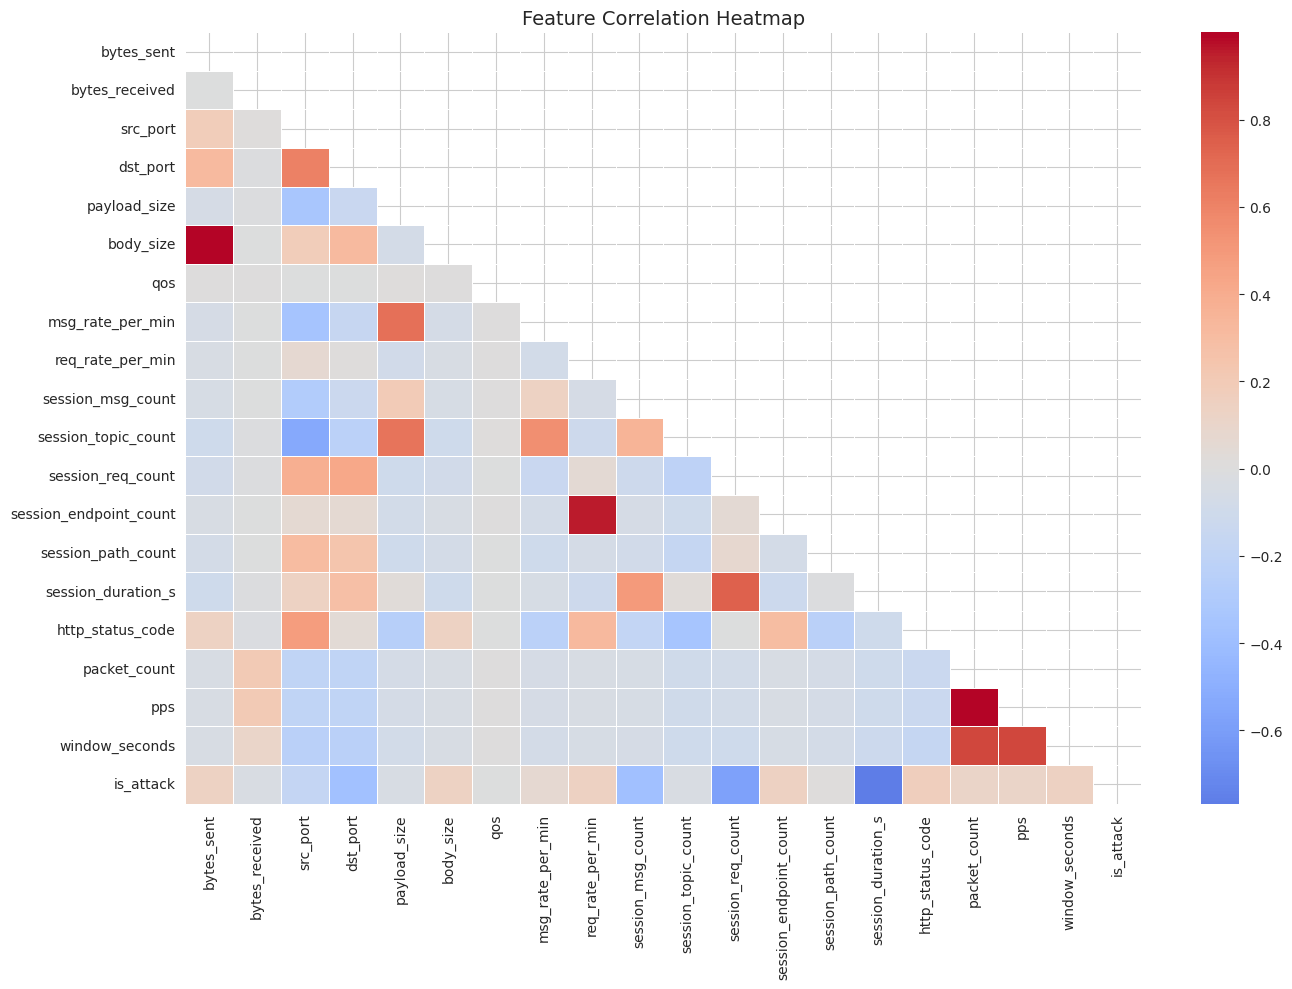


Top 15 features correlated with is_attack:
session_duration_s        0.7678
session_req_count         0.5785
session_msg_count         0.3878
dst_port                  0.3773
src_port                  0.1751
http_status_code          0.1674
session_endpoint_count    0.1503
req_rate_per_min          0.1470
window_seconds            0.1456
bytes_sent                0.1404
body_size                 0.1403
packet_count              0.1133
pps                       0.1133
msg_rate_per_min          0.0648
payload_size              0.0361
Name: is_attack, dtype: float64


In [7]:
# ================================================================
# Cell 5: Correlation Heatmap & Numerical Statistics
# ================================================================
# Descriptive stats for numerical features
num_cols = df.select_dtypes(include=[np.number]).columns.tolist()
print(f"Numerical features ({len(num_cols)}):")
print(df[num_cols].describe().T.round(2))

# Correlation heatmap of numerical features vs is_attack
plt.figure(figsize=(14, 10))
corr_cols = [c for c in num_cols if c != "is_attack"] + ["is_attack"]
corr_matrix = df[corr_cols].corr()
mask = np.triu(np.ones_like(corr_matrix, dtype=bool))
sns.heatmap(corr_matrix, mask=mask, annot=False, cmap="coolwarm",
            center=0, linewidths=0.5, fmt=".2f")
plt.title("Feature Correlation Heatmap", fontsize=14)
plt.tight_layout()
plt.show()

# Top correlated features with target
print("\nTop 15 features correlated with is_attack:")
target_corr = corr_matrix["is_attack"].drop("is_attack").abs().sort_values(ascending=False)
print(target_corr.head(15).round(4))

# Cell 6: Data Cleaning & Preprocessing

In [8]:
# ================================================================
# Cell 6: Data Cleaning & Preprocessing
# ================================================================
data = df.copy()

# --- Drop columns not useful for binary classification ---
drop_cols = [
    # Identifiers / raw text — not generalizable
    "@timestamp", "src_ip", "dst_ip", "client_id", "topic",
    "http_endpoint", "user_agent", "coap_path",
    "username", "username_tried", "attack_name",
    # Target leakage — attack_type directly reveals is_attack
    "attack_type",
    # Target leakage — in our honeypot ALL benign=internal+known, ALL attack=external+unknown
    "is_internal", "is_known_device",
    # Sparse / not useful
    "command",
]
data.drop(columns=[c for c in drop_cols if c in data.columns], inplace=True)
print(f"Dropped {len(drop_cols)} identifier/leaky columns")

# --- Replace "synthetic" marker (from SMOTE) with NaN to avoid artifact leakage ---
data.replace("synthetic", np.nan, inplace=True)

# --- Fix boolean columns stored as object ---
bool_fix = ["retain", "is_known_topic", "is_known_path", "login_success", "login_attempt"]
for col in bool_fix:
    if col in data.columns:
        data[col] = data[col].map({"True": 1, "False": 0, True: 1, False: 0,
                                    "true": 1, "false": 0}).astype("float64")
print(f"Fixed {len(bool_fix)} boolean columns")

# --- Convert target to int ---
data["is_attack"] = data["is_attack"].astype(int)

# --- Fill NaN with 0 (protocol-specific fields not applicable = 0) ---
nan_before = data.isnull().sum().sum()
data.fillna(0, inplace=True)
print(f"Filled {nan_before:,} NaN values with 0")

print(f"\nCleaned shape: {data.shape}")
print(f"Remaining NaN: {data.isnull().sum().sum()}")
print(f"\nColumn types after cleaning:")
print(data.dtypes.value_counts())

Dropped 15 identifier/leaky columns
Fixed 5 boolean columns
Filled 304,416 NaN values with 0

Cleaned shape: (33311, 32)
Remaining NaN: 0

Column types after cleaning:
float64    24
object      7
int64       1
Name: count, dtype: int64


# Cell 7: Feature Engineering

In [9]:
# ================================================================
# Cell 7: Feature Engineering
# ================================================================
# 1. Bytes ratio — attackers often send more than they receive
data["bytes_ratio"] = data["bytes_sent"] / (data["bytes_received"] + 1)

# 2. Total bytes — overall traffic volume
data["total_bytes"] = data["bytes_sent"] + data["bytes_received"]

# 3. Port class — well-known (0-1023), registered (1024-49151), dynamic (49152+)
def port_class(port):
    if port <= 1023:
        return 0  # well-known
    elif port <= 49151:
        return 1  # registered
    else:
        return 2  # dynamic/ephemeral

data["src_port_class"] = data["src_port"].apply(port_class)
data["dst_port_class"] = data["dst_port"].apply(port_class)

# 4. High rate flag — sessions with abnormally high request/message rates
rate_cols = ["msg_rate_per_min", "req_rate_per_min"]
for col in rate_cols:
    if col in data.columns:
        threshold = data[col][data[col] > 0].quantile(0.90) if (data[col] > 0).any() else 0
        data[f"{col}_high"] = (data[col] > threshold).astype(int)

# 5. Session intensity — rate × count interaction
if "msg_rate_per_min" in data.columns and "session_msg_count" in data.columns:
    data["mqtt_session_intensity"] = data["msg_rate_per_min"] * data["session_msg_count"]

if "req_rate_per_min" in data.columns and "session_req_count" in data.columns:
    data["http_session_intensity"] = data["req_rate_per_min"] * data["session_req_count"]

# 6. Payload to bytes ratio
if "payload_size" in data.columns:
    data["payload_bytes_ratio"] = data["payload_size"] / (data["total_bytes"] + 1)

# 7. Session diversity — how many different topics/endpoints/paths visited
diversity_cols = ["session_topic_count", "session_endpoint_count", "session_path_count"]
data["session_diversity"] = data[[c for c in diversity_cols if c in data.columns]].sum(axis=1)

print(f"Engineered features added. New shape: {data.shape}")
print(f"\nNew features:")
new_feats = ["bytes_ratio", "total_bytes", "src_port_class", "dst_port_class",
             "msg_rate_per_min_high", "req_rate_per_min_high",
             "mqtt_session_intensity", "http_session_intensity",
             "payload_bytes_ratio", "session_diversity"]
for f in new_feats:
    if f in data.columns:
        print(f"  {f}: mean={data[f].mean():.4f}, std={data[f].std():.4f}")

Engineered features added. New shape: (33311, 42)

New features:
  bytes_ratio: mean=6037.2541, std=28292.7156
  total_bytes: mean=6038.3735, std=28292.5114
  src_port_class: mean=0.8175, std=0.7904
  dst_port_class: mean=0.6853, std=0.4644
  msg_rate_per_min_high: mean=0.0252, std=0.1569
  req_rate_per_min_high: mean=0.0554, std=0.2287
  mqtt_session_intensity: mean=1751.4460, std=11071.6547
  http_session_intensity: mean=142359.5007, std=727654.7124
  payload_bytes_ratio: mean=0.2152, std=0.4071
  session_diversity: mean=90.6645, std=394.3620


# Cell 8: Feature Selection (Variance Threshold + Correlation Removal)

In [10]:
# ================================================================
# Cell 8: Feature Selection
# ================================================================
from sklearn.feature_selection import VarianceThreshold

# --- Encode categorical columns first ---
cat_cols = ["log_type", "protocol", "mqtt_action", "http_method",
            "coap_method", "coap_response_code", "eventid"]
cat_cols = [c for c in cat_cols if c in data.columns]
data = pd.get_dummies(data, columns=cat_cols, drop_first=False)
print(f"After one-hot encoding: {data.shape}")

# --- 1. Variance Threshold: remove near-zero variance features ---
X_temp = data.drop(columns=["is_attack"])
selector = VarianceThreshold(threshold=0.01)
selector.fit(X_temp)
low_var_cols = X_temp.columns[~selector.get_support()].tolist()
if low_var_cols:
    data.drop(columns=low_var_cols, inplace=True)
    print(f"\nDropped {len(low_var_cols)} low-variance features: {low_var_cols[:10]}{'...' if len(low_var_cols) > 10 else ''}")
else:
    print("\nNo low-variance features found")

# --- 2. Remove highly correlated features (>0.95) ---
X_temp = data.drop(columns=["is_attack"])
corr_abs = X_temp.corr().abs()
upper = corr_abs.where(np.triu(np.ones(corr_abs.shape), k=1).astype(bool))
high_corr_cols = [col for col in upper.columns if any(upper[col] > 0.95)]
if high_corr_cols:
    data.drop(columns=high_corr_cols, inplace=True)
    print(f"Dropped {len(high_corr_cols)} highly correlated features (>0.95): {high_corr_cols[:10]}{'...' if len(high_corr_cols) > 10 else ''}")
else:
    print("No highly correlated features found")

print(f"\nFinal shape after feature selection: {data.shape}")
print(f"Features: {data.shape[1] - 1}")  # minus target

After one-hot encoding: (33311, 70)

Dropped 17 low-variance features: ['qos', 'retain', 'login_success', 'login_attempt', 'protocol_ICMP', 'protocol_UDP', 'mqtt_action_subscribe', 'http_method_CONNECT', 'http_method_HEAD', 'http_method_PUT']...
Dropped 16 highly correlated features (>0.95): ['body_size', 'session_endpoint_count', 'pps', 'bytes_ratio', 'total_bytes', 'http_session_intensity', 'session_diversity', 'log_type_network', 'protocol_CoAP', 'protocol_MQTT']...

Final shape after feature selection: (33311, 37)
Features: 36


# Cell 9: Train/Test Split

In [11]:
# ================================================================
# Cell 9: Train/Test Split
# ================================================================
from sklearn.model_selection import train_test_split

X = data.drop(columns=["is_attack"])
y = data["is_attack"]

# 80/20 stratified split
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

print(f"Train: {X_train.shape[0]:,} samples ({y_train.sum():,} attacks, {y_train.mean():.2%})")
print(f"Test:  {X_test.shape[0]:,} samples ({y_test.sum():,} attacks, {y_test.mean():.2%})")
print(f"\nFeatures: {X_train.shape[1]}")
print(f"Train attack ratio: {y_train.mean():.2%}")
print(f"Test attack ratio:  {y_test.mean():.2%}")

Train: 26,648 samples (18,395 attacks, 69.03%)
Test:  6,663 samples (4,600 attacks, 69.04%)

Features: 36
Train attack ratio: 69.03%
Test attack ratio:  69.04%


# Cell 10: XGBoost Baseline Training

In [12]:
# ================================================================
# Cell 10: XGBoost Baseline Training
# ================================================================
from xgboost import XGBClassifier
from sklearn.metrics import (classification_report, confusion_matrix,
                             roc_auc_score, roc_curve, precision_recall_curve,
                             average_precision_score)

# scale_pos_weight handles class imbalance
scale = y_train.value_counts()[0] / y_train.value_counts()[1]
print(f"scale_pos_weight: {scale:.2f}")

model_binary = XGBClassifier(
    n_estimators=200,
    max_depth=6,
    learning_rate=0.1,
    scale_pos_weight=scale,
    random_state=42,
    eval_metric="logloss",
    use_label_encoder=False,
)

model_binary.fit(X_train, y_train)

# Predict
y_pred = model_binary.predict(X_test)
y_prob = model_binary.predict_proba(X_test)[:, 1]

print("\n" + "=" * 60)
print("BASELINE BINARY CLASSIFICATION RESULTS")
print("=" * 60)
print(f"\nClassification Report:")
print(classification_report(y_test, y_pred, target_names=["Benign", "Attack"]))
print(f"ROC AUC: {roc_auc_score(y_test, y_prob):.4f}")
print(f"Average Precision (PR AUC): {average_precision_score(y_test, y_prob):.4f}")

scale_pos_weight: 0.45

BASELINE BINARY CLASSIFICATION RESULTS

Classification Report:
              precision    recall  f1-score   support

      Benign       1.00      1.00      1.00      2063
      Attack       1.00      1.00      1.00      4600

    accuracy                           1.00      6663
   macro avg       1.00      1.00      1.00      6663
weighted avg       1.00      1.00      1.00      6663

ROC AUC: 1.0000
Average Precision (PR AUC): 1.0000


# Cell 11: Hyperparameter Tuning (RandomizedSearchCV)

In [13]:
# ================================================================
# Cell 11: Hyperparameter Tuning (RandomizedSearchCV)
# ================================================================
from sklearn.model_selection import RandomizedSearchCV

param_dist = {
    "n_estimators": [100, 200, 300, 500],
    "max_depth": [3, 4, 5, 6, 8, 10],
    "learning_rate": [0.01, 0.05, 0.1, 0.2],
    "subsample": [0.6, 0.7, 0.8, 0.9, 1.0],
    "colsample_bytree": [0.6, 0.7, 0.8, 0.9, 1.0],
    "min_child_weight": [1, 3, 5, 7],
    "gamma": [0, 0.1, 0.2, 0.3],
}

xgb_tuner = XGBClassifier(
    scale_pos_weight=scale,
    random_state=42,
    eval_metric="logloss",
    use_label_encoder=False,
)

random_search = RandomizedSearchCV(
    xgb_tuner,
    param_distributions=param_dist,
    n_iter=30,
    scoring="f1",
    cv=3,
    random_state=42,
    verbose=1,
    n_jobs=-1,
)

random_search.fit(X_train, y_train)

print(f"\nBest F1 score (CV): {random_search.best_score_:.4f}")
print(f"\nBest parameters:")
for param, val in random_search.best_params_.items():
    print(f"  {param}: {val}")

# Use best model
model_binary = random_search.best_estimator_
y_pred = model_binary.predict(X_test)
y_prob = model_binary.predict_proba(X_test)[:, 1]

print(f"\n{'=' * 60}")
print("TUNED MODEL RESULTS")
print("=" * 60)
print(classification_report(y_test, y_pred, target_names=["Benign", "Attack"]))
print(f"ROC AUC: {roc_auc_score(y_test, y_prob):.4f}")
print(f"Average Precision: {average_precision_score(y_test, y_prob):.4f}")

Fitting 3 folds for each of 30 candidates, totalling 90 fits

Best F1 score (CV): 0.9997

Best parameters:
  subsample: 1.0
  n_estimators: 300
  min_child_weight: 3
  max_depth: 8
  learning_rate: 0.2
  gamma: 0.1
  colsample_bytree: 0.7

TUNED MODEL RESULTS
              precision    recall  f1-score   support

      Benign       1.00      1.00      1.00      2063
      Attack       1.00      1.00      1.00      4600

    accuracy                           1.00      6663
   macro avg       1.00      1.00      1.00      6663
weighted avg       1.00      1.00      1.00      6663

ROC AUC: 1.0000
Average Precision: 1.0000


# Cell 12: Evaluation Visualizations — Confusion Matrix, ROC & PR Curves

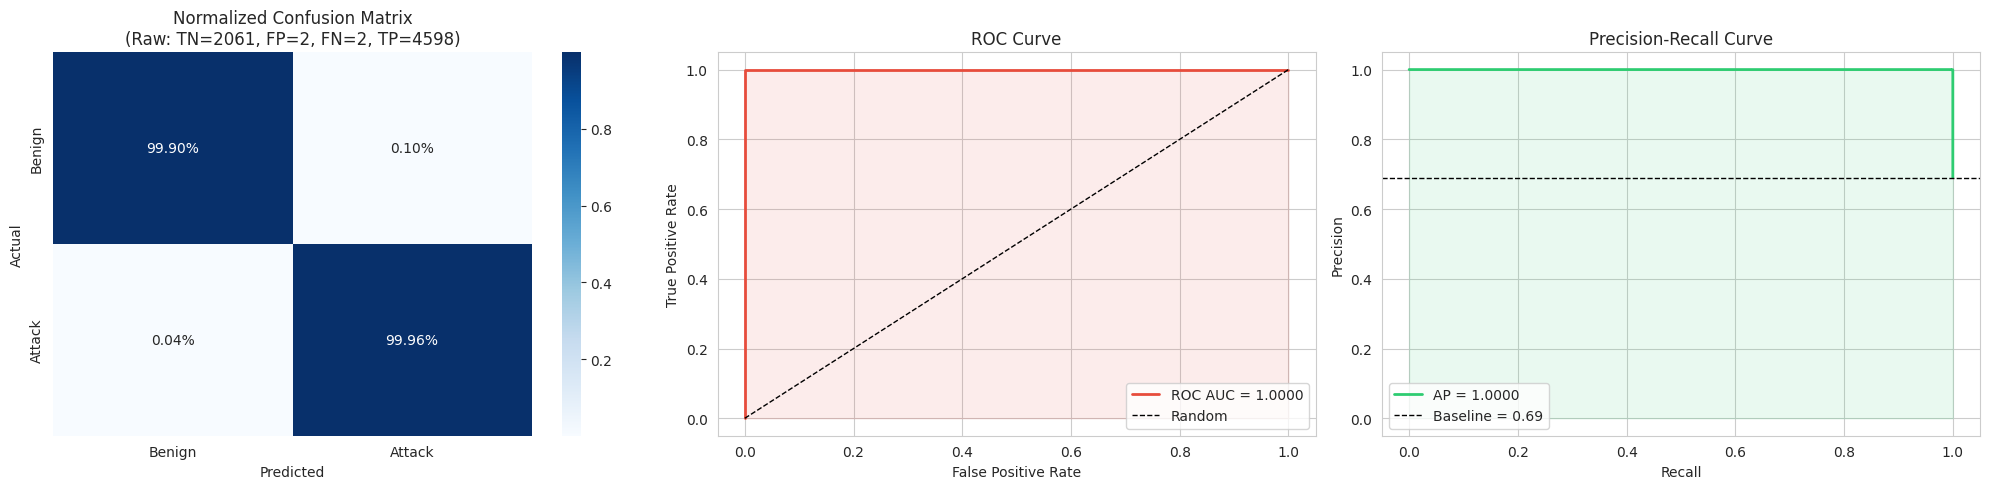

In [14]:
# ================================================================
# Cell 12: Evaluation Visualizations
# ================================================================
fig, axes = plt.subplots(1, 3, figsize=(20, 5))

# 1. Confusion Matrix (normalized)
cm = confusion_matrix(y_test, y_pred)
cm_norm = cm.astype('float') / cm.sum(axis=1)[:, np.newaxis]
sns.heatmap(cm_norm, annot=True, fmt='.2%', cmap='Blues', ax=axes[0],
            xticklabels=['Benign', 'Attack'], yticklabels=['Benign', 'Attack'])
axes[0].set_xlabel('Predicted')
axes[0].set_ylabel('Actual')
axes[0].set_title(f'Normalized Confusion Matrix\n(Raw: TN={cm[0,0]}, FP={cm[0,1]}, FN={cm[1,0]}, TP={cm[1,1]})')

# 2. ROC Curve
fpr, tpr, _ = roc_curve(y_test, y_prob)
auc_score = roc_auc_score(y_test, y_prob)
axes[1].plot(fpr, tpr, color='#e74c3c', lw=2, label=f'ROC AUC = {auc_score:.4f}')
axes[1].plot([0, 1], [0, 1], 'k--', lw=1, label='Random')
axes[1].fill_between(fpr, tpr, alpha=0.1, color='#e74c3c')
axes[1].set_xlabel('False Positive Rate')
axes[1].set_ylabel('True Positive Rate')
axes[1].set_title('ROC Curve')
axes[1].legend(loc='lower right')

# 3. Precision-Recall Curve (better for imbalanced data)
precision, recall, _ = precision_recall_curve(y_test, y_prob)
ap = average_precision_score(y_test, y_prob)
axes[2].plot(recall, precision, color='#2ecc71', lw=2, label=f'AP = {ap:.4f}')
axes[2].axhline(y=y_test.mean(), color='k', linestyle='--', lw=1, label=f'Baseline = {y_test.mean():.2f}')
axes[2].fill_between(recall, precision, alpha=0.1, color='#2ecc71')
axes[2].set_xlabel('Recall')
axes[2].set_ylabel('Precision')
axes[2].set_title('Precision-Recall Curve')
axes[2].legend(loc='lower left')

plt.tight_layout()
plt.show()

# Cell 13: 5-Fold Stratified Cross-Validation

In [15]:
# ================================================================
# Cell 13: 5-Fold Stratified Cross-Validation
# ================================================================
from sklearn.model_selection import StratifiedKFold, cross_validate

cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

scoring = {
    'accuracy': 'accuracy',
    'f1': 'f1',
    'precision': 'precision',
    'recall': 'recall',
    'roc_auc': 'roc_auc',
}

cv_results = cross_validate(
    model_binary, X, y,
    cv=cv,
    scoring=scoring,
    return_train_score=True,
    n_jobs=-1,
)

print('=' * 60)
print('5-FOLD STRATIFIED CROSS-VALIDATION RESULTS')
print('=' * 60)
print(f"{'Metric':<12} {'Train Mean':>12} {'Test Mean':>12} {'Test Std':>10}")
print('-' * 50)
for metric in ['accuracy', 'f1', 'precision', 'recall', 'roc_auc']:
    train_mean = cv_results[f'train_{metric}'].mean()
    test_mean = cv_results[f'test_{metric}'].mean()
    test_std = cv_results[f'test_{metric}'].std()
    print(f"{metric:<12} {train_mean:>12.4f} {test_mean:>12.4f} {test_std:>10.4f}")

# Check for overfitting
train_acc = cv_results['train_accuracy'].mean()
test_acc = cv_results['test_accuracy'].mean()
gap = train_acc - test_acc
print(f"\nOverfit gap (train-test accuracy): {gap:.4f}")
if gap > 0.05:
    print('⚠️  Potential overfitting detected (gap > 5%)')
else:
    print('✓ No significant overfitting')

5-FOLD STRATIFIED CROSS-VALIDATION RESULTS
Metric         Train Mean    Test Mean   Test Std
--------------------------------------------------
accuracy           0.9999       0.9994     0.0002
f1                 1.0000       0.9996     0.0002
precision          1.0000       0.9995     0.0003
recall             0.9999       0.9997     0.0003
roc_auc            1.0000       1.0000     0.0000

Overfit gap (train-test accuracy): 0.0005
✓ No significant overfitting


# Cell 14: Feature Importance (Top 20)

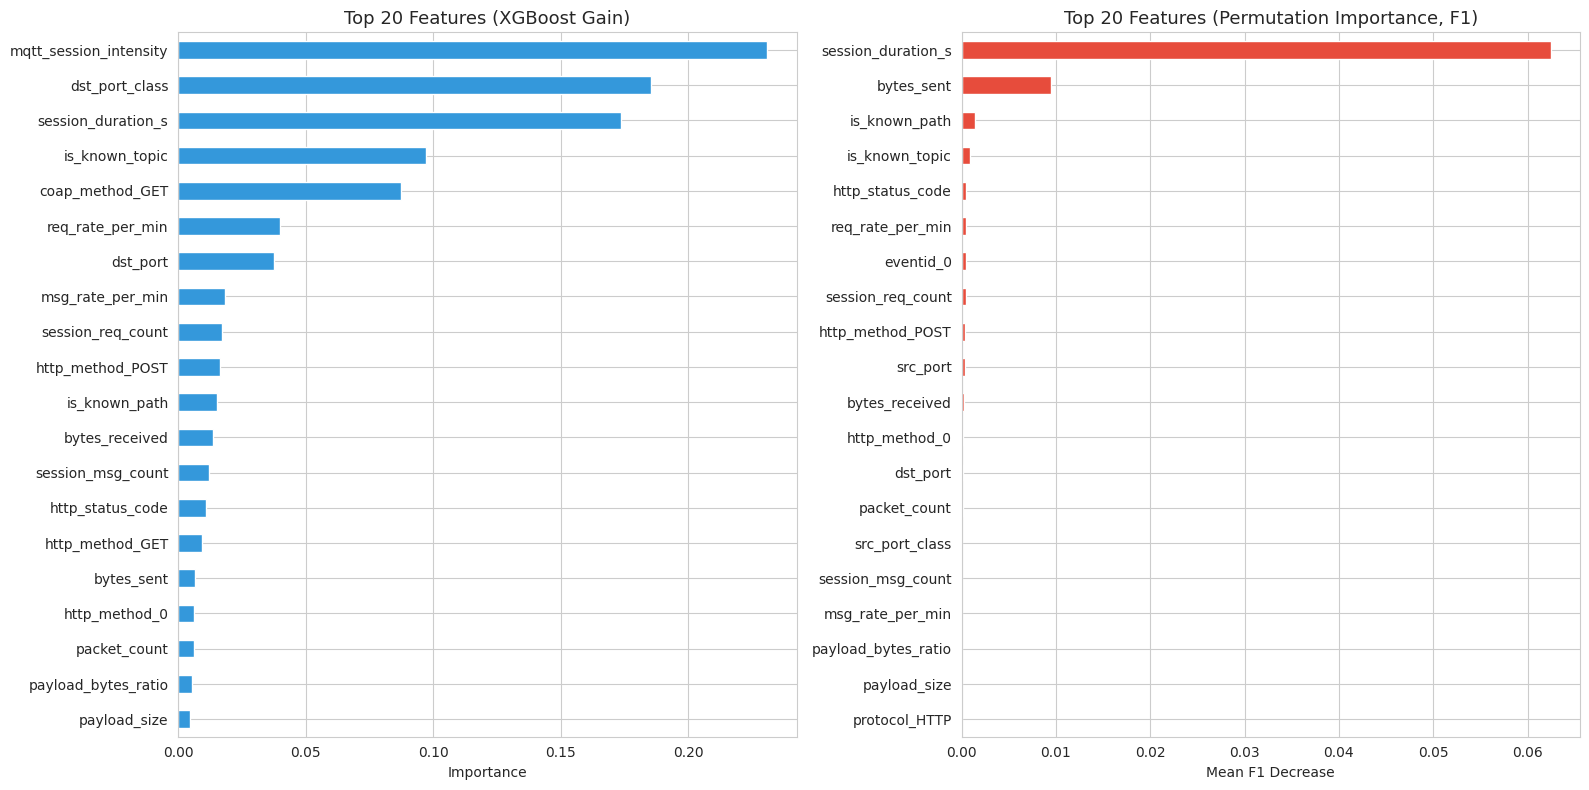


Top 10 features by both methods:
  Common in both: {'req_rate_per_min', 'is_known_topic', 'session_req_count', 'http_method_POST', 'session_duration_s'}
  Only in Gain: {'dst_port', 'dst_port_class', 'mqtt_session_intensity', 'coap_method_GET', 'msg_rate_per_min'}
  Only in Permutation: {'eventid_0', 'http_status_code', 'src_port', 'is_known_path', 'bytes_sent'}


In [16]:
# ================================================================
# Cell 14: Feature Importance (Top 20)
# ================================================================
fig, axes = plt.subplots(1, 2, figsize=(16, 8))

# 1. XGBoost built-in importance (gain)
importance = model_binary.feature_importances_
feat_imp = pd.Series(importance, index=X_train.columns).nlargest(20)
feat_imp.sort_values().plot.barh(ax=axes[0], color='#3498db')
axes[0].set_title('Top 20 Features (XGBoost Gain)', fontsize=13)
axes[0].set_xlabel('Importance')

# 2. Permutation importance (more robust)
from sklearn.inspection import permutation_importance

perm_imp = permutation_importance(
    model_binary, X_test, y_test,
    n_repeats=10, random_state=42, n_jobs=-1, scoring='f1'
)
perm_imp_series = pd.Series(perm_imp.importances_mean, index=X_test.columns).nlargest(20)
perm_imp_series.sort_values().plot.barh(ax=axes[1], color='#e74c3c')
axes[1].set_title('Top 20 Features (Permutation Importance, F1)', fontsize=13)
axes[1].set_xlabel('Mean F1 Decrease')

plt.tight_layout()
plt.show()

# Summary table
print('\nTop 10 features by both methods:')
top_gain = set(feat_imp.index[:10])
top_perm = set(perm_imp_series.index[:10])
common = top_gain & top_perm
print(f'  Common in both: {common}')
print(f'  Only in Gain: {top_gain - top_perm}')
print(f'  Only in Permutation: {top_perm - top_gain}')

# Cell 15: Save Model

In [17]:
# ================================================================
# Cell 15: Save Model
# ================================================================
import pickle
import json as json_lib

# Save the trained model
with open('xgboost_binary.pkl', 'wb') as f:
    pickle.dump(model_binary, f)

# Save metadata
metadata = {
    'model': 'XGBoost Binary Classifier',
    'features': list(X_train.columns),
    'n_features': X_train.shape[1],
    'train_samples': X_train.shape[0],
    'test_samples': X_test.shape[0],
    'best_params': random_search.best_params_,
    'cv_f1_mean': float(cv_results['test_f1'].mean()),
    'cv_f1_std': float(cv_results['test_f1'].std()),
    'test_roc_auc': float(roc_auc_score(y_test, y_prob)),
    'test_avg_precision': float(average_precision_score(y_test, y_prob)),
}

with open('xgboost_binary_metadata.json', 'w') as f:
    json_lib.dump(metadata, f, indent=2)

print('Saved: xgboost_binary.pkl')
print('Saved: xgboost_binary_metadata.json')
print(f"\nModel summary:")
for k, v in metadata.items():
    if k != 'features':
        print(f"  {k}: {v}")

Saved: xgboost_binary.pkl
Saved: xgboost_binary_metadata.json

Model summary:
  model: XGBoost Binary Classifier
  n_features: 36
  train_samples: 26648
  test_samples: 6663
  best_params: {'subsample': 1.0, 'n_estimators': 300, 'min_child_weight': 3, 'max_depth': 8, 'learning_rate': 0.2, 'gamma': 0.1, 'colsample_bytree': 0.7}
  cv_f1_mean: 0.9995869115797245
  cv_f1_std: 0.00015978609688962648
  test_roc_auc: 0.999997260216232
  test_avg_precision: 0.9999987705133722
